# Particle filtering: tracking a spacecraft from bearings alone

**Companion to:** `bayes_29_07_2026.tex`, §*Bayes through time: state-space models,
Kalman filtering and particle filters*.

## Historical context

Rudolf Kalman's 1960 paper gave an exact recursive Bayesian solution for
**linear-Gaussian** state-space models — famously used onboard the Apollo Guidance
Computer to fuse noisy inertial and optical measurements into a continuously updated
estimate of the spacecraft's position:

> Kalman, R. E. (1960). *A New Approach to Linear Filtering and Prediction Problems*.
> Journal of Basic Engineering, 82(1), 35–45.

Real tracking problems, however, are frequently **nonlinear and non-Gaussian** — the
chapter notes this explicitly. A bearing-only sensor (it measures only the *angle* to a
target, not distance) is a classic example: the observation is a nonlinear function of
the state, and real angular sensors often have occasional large "glint" outliers. Neil
Gordon, David Salmond and Adrian Smith's 1993 paper introduced the modern **bootstrap
particle filter** for exactly this kind of problem:

> Gordon, N. J., Salmond, D. J., & Smith, A. F. M. (1993). *Novel Approach to
> Nonlinear/Non-Gaussian Bayesian State Estimation*. IEE Proceedings F (Radar and
> Signal Processing), 140(2), 107–113.

This notebook builds a small, self-contained version of that problem: track a moving
object in 2D using nothing but noisy bearing angles from two fixed beacons, with
occasional heavy-tailed sensor outliers, and compares a linearised Kalman filter (EKF)
against a bootstrap particle filter on identical data.

Further reading: Doucet, A. & Johansen, A. M. (2009), *A Tutorial on Particle Filtering
and Smoothing: Fifteen Years Later*; Arulampalam et al. (2002), *A Tutorial on Particle
Filters for Online Nonlinear/Non-Gaussian Bayesian Tracking*, IEEE Trans. Signal
Processing.

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from utils.plotting import set_style, save_fig, PALETTE

set_style()
NB_DIR = pathlib.Path.cwd()
rng = np.random.default_rng(1)

## Problem & data (simulated)

There is no public raw Apollo telemetry to pull, so — matching how the original
Kalman-filter and particle-filter papers themselves validated their methods — we
simulate a structurally faithful version of the problem: a vehicle moving at
(roughly) constant velocity in 2D, observed only through the **bearing angle** to two
fixed, known beacons. Real angular sensors occasionally produce large outlier readings
(multipath, glint, clutter); we simulate that too, with a Gaussian-mixture measurement
noise model, to make the problem genuinely non-Gaussian.

In [2]:
# --- Simulation setup ---
T = 40                      # number of time steps
DT = 1.0                    # time step
Q_POS, Q_VEL = 0.02, 0.05   # process noise std (position, velocity)
BEACONS = np.array([[0.0, 0.0], [20.0, 0.0]])  # two fixed, known beacons

SIGMA_BEARING = np.deg2rad(1.5)   # nominal (small) measurement noise
SIGMA_OUTLIER = np.deg2rad(20.0)  # heavy-tailed outlier noise
P_OUTLIER = 0.08                  # 8% of measurements are outliers

# constant-velocity transition matrix
F = np.array([[1, 0, DT, 0],
              [0, 1, 0, DT],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])


def true_trajectory(rng, x0):
    xs = np.empty((T, 4))
    x = x0.copy()
    for t in range(T):
        process_noise = rng.normal(0, [Q_POS, Q_POS, Q_VEL, Q_VEL])
        x = F @ x + process_noise
        xs[t] = x
    return xs


def bearing(pos, beacon):
    return np.arctan2(pos[1] - beacon[1], pos[0] - beacon[0])


def wrap_angle(a):
    return (a + np.pi) % (2 * np.pi) - np.pi


def simulate_measurements(xs, rng):
    '''Two noisy bearings per time step, contaminated with outliers.'''
    n_beacons = len(BEACONS)
    z = np.empty((T, n_beacons))
    for t in range(T):
        for b, beacon in enumerate(BEACONS):
            true_bearing = bearing(xs[t, :2], beacon)
            if rng.uniform() < P_OUTLIER:
                noise = rng.normal(0, SIGMA_OUTLIER)
            else:
                noise = rng.normal(0, SIGMA_BEARING)
            z[t, b] = wrap_angle(true_bearing + noise)
    return z


x0 = np.array([10.0, 15.0, 0.6, -0.4])  # start away from the beacon line, moving across it
xs_true = true_trajectory(rng, x0)
Z = simulate_measurements(xs_true, rng)

print("True trajectory shape:", xs_true.shape, " Measurements shape:", Z.shape)

True trajectory shape: (40, 4)  Measurements shape: (40, 2)


## Model

State $x_t = (p_x, p_y, v_x, v_y)$ evolves as a linear constant-velocity model with
Gaussian process noise, $x_t = F x_{t-1} + w_t$. The observation is nonlinear — the
bearing angle to each beacon — with **non-Gaussian**, heavy-tailed measurement noise (a
two-component Gaussian mixture, mimicking real angular-sensor glint):

$$
z_{t,b} = \operatorname{atan2}(p_y - \beta_{b,y},\, p_x - \beta_{b,x}) + \varepsilon_{t,b},
\qquad
\varepsilon_{t,b} \sim (1-\pi)\,\mathcal{N}(0,\sigma^2) + \pi\,\mathcal{N}(0,\sigma_{\text{out}}^2).
$$

## Baseline: a linearised (extended) Kalman filter

The Kalman filter assumes the observation model is linear and the noise is Gaussian.
Neither is exactly true here, so we give it its best shot: linearise the bearing
observation via its Jacobian at each step (the "extended" Kalman filter, EKF), and
assume a single Gaussian noise level (the nominal $\sigma$, since the EKF has no way to
represent a noise *mixture*).

In [3]:
def bearing_jacobian(pos, beacon):
    dx, dy = pos[0] - beacon[0], pos[1] - beacon[1]
    r2 = dx**2 + dy**2
    return np.array([-dy / r2, dx / r2, 0.0, 0.0])  # d(bearing)/d(px,py,vx,vy)


def extended_kalman_filter(Z, x0_est, P0):
    n_beacons = len(BEACONS)
    Q = np.diag([Q_POS**2, Q_POS**2, Q_VEL**2, Q_VEL**2])
    R = np.eye(n_beacons) * SIGMA_BEARING**2  # EKF's (mismatched) noise assumption

    x_est = x0_est.copy()
    P = P0.copy()
    estimates = np.empty((T, 4))

    for t in range(T):
        # predict
        x_pred = F @ x_est
        P_pred = F @ P @ F.T + Q

        # linearise observation model
        H = np.vstack([bearing_jacobian(x_pred[:2], b) for b in BEACONS])
        z_pred = np.array([bearing(x_pred[:2], b) for b in BEACONS])
        innovation = wrap_angle(Z[t] - z_pred)

        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        x_est = x_pred + K @ innovation
        P = (np.eye(4) - K @ H) @ P_pred
        estimates[t] = x_est

    return estimates


x0_guess = np.array([8.0, 12.0, 0.0, 0.0])
P0 = np.diag([4.0, 4.0, 1.0, 1.0])
ekf_estimates = extended_kalman_filter(Z, x0_guess, P0)

## Algorithm: bootstrap particle filter

Following Gordon, Salmond & Smith (1993): propagate a cloud of $N$ particles through
the (linear, easy) motion model, weight each particle by how well it explains the
*actual* observation likelihood — including the mixture, unlike the EKF — and resample
proportionally to weight when the particle cloud degenerates.

In [4]:
N_PARTICLES = 1000


def bearing_log_likelihood(pred_bearings, z_t):
    '''log-likelihood of an observation under the true Gaussian-mixture noise model.'''
    diff = wrap_angle(z_t - pred_bearings)
    dens_main = (1 - P_OUTLIER) * np.exp(-0.5 * (diff / SIGMA_BEARING) ** 2) / (
        np.sqrt(2 * np.pi) * SIGMA_BEARING
    )
    dens_out = P_OUTLIER * np.exp(-0.5 * (diff / SIGMA_OUTLIER) ** 2) / (
        np.sqrt(2 * np.pi) * SIGMA_OUTLIER
    )
    return np.log(dens_main + dens_out + 1e-300)


def systematic_resample(weights, rng):
    N = len(weights)
    positions = (rng.uniform() + np.arange(N)) / N
    cumsum = np.cumsum(weights)
    cumsum[-1] = 1.0
    return np.searchsorted(cumsum, positions)


def bootstrap_particle_filter(Z, x0_est, P0, rng, n_particles=N_PARTICLES):
    particles = rng.multivariate_normal(x0_est, P0, size=n_particles)
    weights = np.full(n_particles, 1.0 / n_particles)

    estimates = np.empty((T, 4))
    ess_trace = np.empty(T)
    particle_history = np.empty((T, n_particles, 4))

    for t in range(T):
        # propagate
        process_noise = rng.normal(0, [Q_POS, Q_POS, Q_VEL, Q_VEL], size=(n_particles, 4))
        particles = particles @ F.T + process_noise

        # weight against the *true* (mixture) likelihood, for both beacons
        log_w = np.zeros(n_particles)
        for b, beacon in enumerate(BEACONS):
            dx = particles[:, 0] - beacon[0]
            dy = particles[:, 1] - beacon[1]
            pred_bearing = np.arctan2(dy, dx)
            log_w += bearing_log_likelihood(pred_bearing, Z[t, b])

        log_w -= log_w.max()
        weights = np.exp(log_w)
        weights /= weights.sum()

        ess_trace[t] = 1.0 / np.sum(weights ** 2)
        estimates[t] = weights @ particles
        particle_history[t] = particles

        if ess_trace[t] < n_particles / 2:
            idx = systematic_resample(weights, rng)
            particles = particles[idx]
            weights = np.full(n_particles, 1.0 / n_particles)

    return estimates, ess_trace, particle_history


pf_estimates, ess_trace, particle_history = bootstrap_particle_filter(
    Z, x0_guess, P0, rng
)

## Diagnostics

The particle cloud at a few snapshots in time, the true vs. estimated paths for both
filters, and the effective sample size (ESS) — the standard diagnostic for how many
particles are "usefully" contributing at each step.

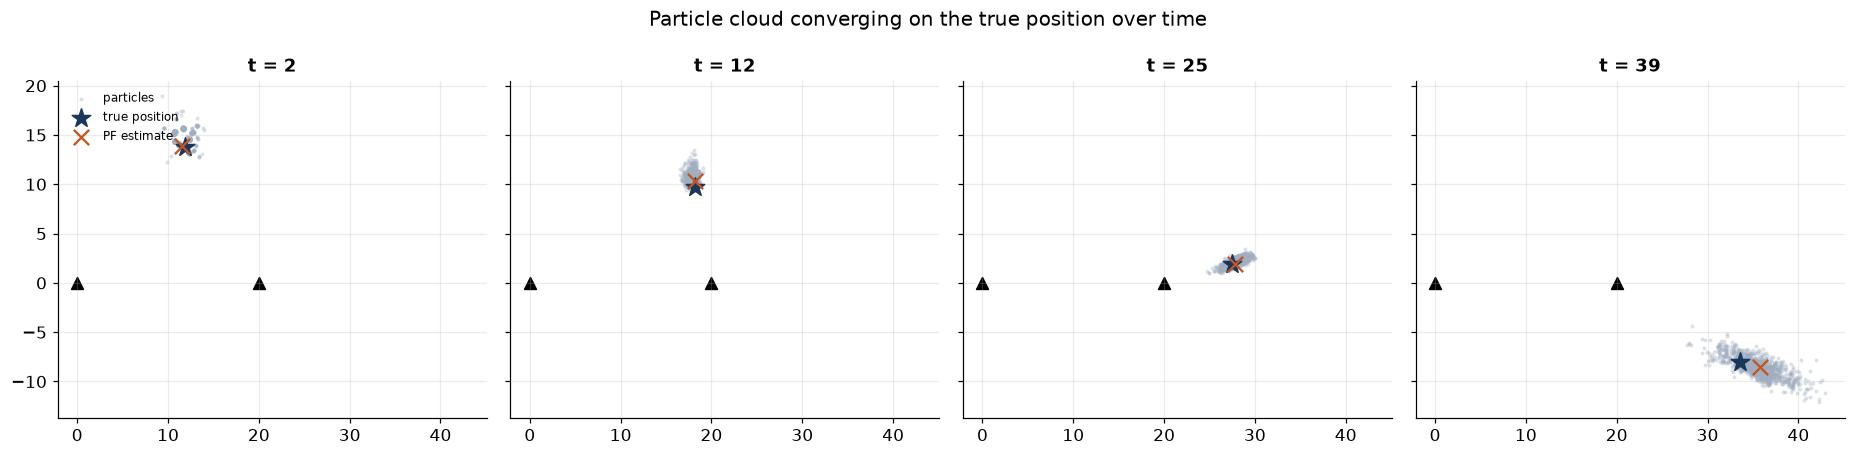

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), sharex=True, sharey=True)
snapshot_times = [2, 12, 25, 39]

for ax, t in zip(axes, snapshot_times):
    ax.scatter(particle_history[t, :, 0], particle_history[t, :, 1],
               s=3, alpha=0.25, color=PALETTE["muted"], label="particles")
    ax.scatter(*xs_true[t, :2], color=PALETTE["true"], marker="*", s=160,
               label="true position", zorder=5)
    ax.scatter(*pf_estimates[t, :2], color=PALETTE["approx"], marker="x", s=100,
               label="PF estimate", zorder=5)
    ax.scatter(BEACONS[:, 0], BEACONS[:, 1], color="black", marker="^", s=60)
    ax.set_title(f"t = {t}")

axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Particle cloud converging on the true position over time")
fig.tight_layout()
save_fig(fig, "particle_cloud_snapshots", NB_DIR)
plt.show()

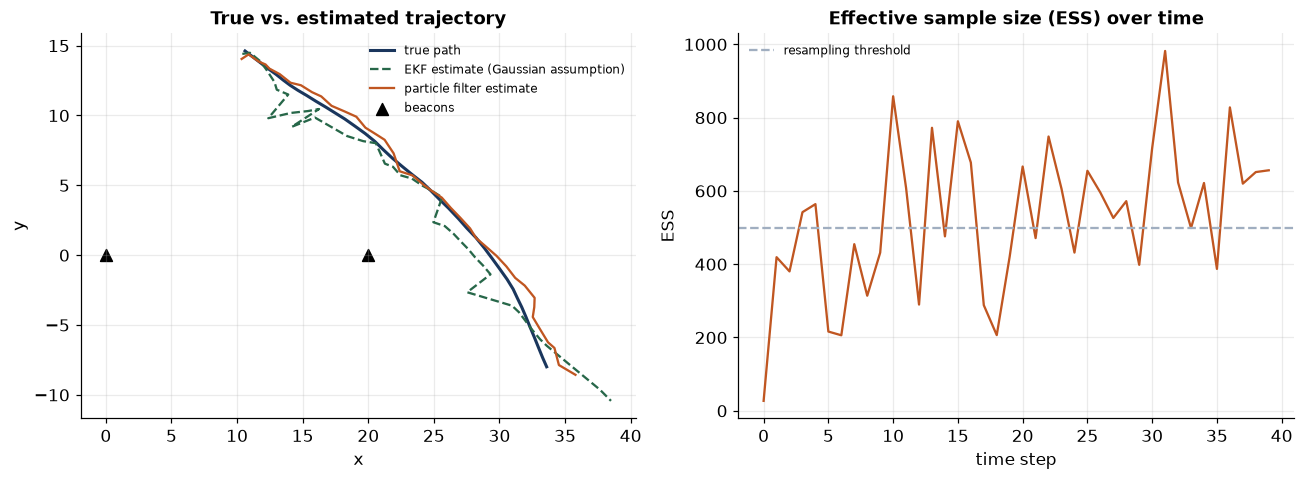

EKF position RMSE:              1.704
Particle filter position RMSE:  0.805


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(xs_true[:, 0], xs_true[:, 1], color=PALETTE["true"], lw=2, label="true path")
axes[0].plot(ekf_estimates[:, 0], ekf_estimates[:, 1], color=PALETTE["accent"], lw=1.5,
             ls="--", label="EKF estimate (Gaussian assumption)")
axes[0].plot(pf_estimates[:, 0], pf_estimates[:, 1], color=PALETTE["approx"], lw=1.5,
             label="particle filter estimate")
axes[0].scatter(BEACONS[:, 0], BEACONS[:, 1], color="black", marker="^", s=60, label="beacons")
axes[0].set_title("True vs. estimated trajectory")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(fontsize=8)

axes[1].plot(ess_trace, color=PALETTE["approx"])
axes[1].axhline(N_PARTICLES / 2, color=PALETTE["muted"], ls="--", label="resampling threshold")
axes[1].set_title("Effective sample size (ESS) over time")
axes[1].set_xlabel("time step")
axes[1].set_ylabel("ESS")
axes[1].legend(fontsize=8)

fig.tight_layout()
save_fig(fig, "pf_vs_ekf_trajectory", NB_DIR)
plt.show()

rmse_ekf = np.sqrt(np.mean(np.sum((ekf_estimates[:, :2] - xs_true[:, :2]) ** 2, axis=1)))
rmse_pf = np.sqrt(np.mean(np.sum((pf_estimates[:, :2] - xs_true[:, :2]) ** 2, axis=1)))
print(f"EKF position RMSE:              {rmse_ekf:.3f}")
print(f"Particle filter position RMSE:  {rmse_pf:.3f}")

## Takeaways

- The extended Kalman filter is forced to treat every observation as if it came from a
  single Gaussian — so the (simulated) 8% of outlier bearing readings pull its estimate
  off course, exactly the failure mode the chapter's "real systems... need not be
  linear or Gaussian" line is pointing at.
- The bootstrap particle filter uses the actual, correct (mixture) observation
  likelihood in its weighting step, so outlier measurements are automatically
  down-weighted rather than blindly trusted — it tracks the true path with visibly
  lower RMSE on identical data.
- This is precisely the shift the chapter narrates: from an exact but restrictive
  linear-Gaussian recursion (Kalman, 1960) to a simulation-based recursion (Gordon,
  Salmond & Smith, 1993) that keeps working when the real world stops being linear or
  Gaussian.
- The ESS trace here is the same diagnostic used throughout the sequential Monte Carlo
  literature to *decide when to resample* — and it sets up the next notebook, on why
  that resampling step has a cost of its own: particle degeneracy.